#  Surface verification and analisys

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.labelsize": 10,
    }
)

In [3]:
df = pd.read_csv("surface_audit.csv")

df["cp_failed"] = df["cp_status"] != "complete"
df["sp_failed"] = ~df["sp_status"].isin(["complete", "complete_missing_optional"])
df["sp_not_attempted"] = df["sp_status"].isin(["missing_dir", "no_split_dir"])
df["any_failed"] = df["cp_failed"] | df["sp_failed"]

if "lh_area_sum" in df.columns and "rh_area_sum" in df.columns:
    df["total_wm_area"] = df["lh_area_sum"] + df["rh_area_sum"]

print(
    f"Loaded {len(df)} rows: {df['subject_id'].nunique()} subjects × {df['split'].nunique()} splits"
)
print(f"\nCP status counts:\n{df['cp_status'].value_counts().to_string()}")
print(f"\nSP status counts:\n{df['sp_status'].value_counts().to_string()}")

Loaded 92 rows: 23 subjects × 4 splits

CP status counts:
cp_status
complete    92

SP status counts:
sp_status
complete_missing_optional    62
partial_fail                 30


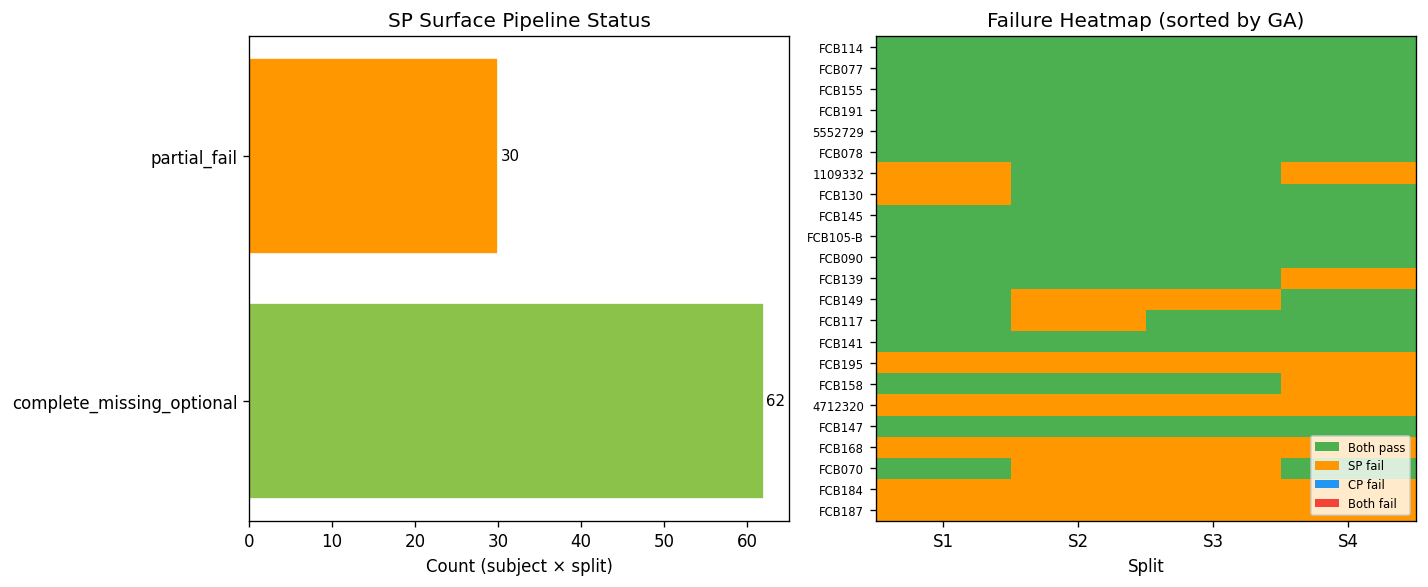

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Panel B: SP pipeline status ---
sp_counts = df["sp_status"].value_counts()
colors_sp = {
    "complete": "#4CAF50",
    "complete_missing_optional": "#8BC34A",
    "partial_fail": "#FF9800",
    "empty_dir": "#F44336",
    "missing_dir": "#9E9E9E",
    "no_split_dir": "#616161",
}
sp_colors = [colors_sp.get(s, "#BDBDBD") for s in sp_counts.index]
axes[0].barh(sp_counts.index, sp_counts.values, color=sp_colors, edgecolor="white")
axes[0].set_xlabel("Count (subject × split)")
axes[0].set_title("SP Surface Pipeline Status")
for i, (v, idx) in enumerate(zip(sp_counts.values, sp_counts.index)):
    axes[0].text(v + 0.3, i, str(v), va="center", fontsize=9)

# --- Panel C: Combined failure heatmap per subject ---
subj_order = df.groupby("subject_id")["GA"].first().sort_values().index
pivot_cp = df.pivot_table(
    index="subject_id", columns="split", values="cp_failed", aggfunc="first"
)
pivot_sp = df.pivot_table(
    index="subject_id", columns="split", values="sp_failed", aggfunc="first"
)
# Encode: 0=both pass, 1=CP fail only, 2=SP fail only, 3=both fail
combined = pivot_cp.astype(int) + pivot_sp.astype(int) * 2
combined = combined.reindex(subj_order)

from matplotlib.colors import ListedColormap

cmap = ListedColormap(["#4CAF50", "#2196F3", "#FF9800", "#F44336"])
im = axes[1].imshow(combined.values, cmap=cmap, aspect="auto", vmin=0, vmax=3)
axes[1].set_yticks(range(len(subj_order)))
axes[1].set_yticklabels(subj_order, fontsize=7)
axes[1].set_xticks(range(len(combined.columns)))
axes[1].set_xticklabels(combined.columns)
axes[1].set_title("Failure Heatmap (sorted by GA)")
axes[1].set_xlabel("Split")

legend_elements = [
    mpatches.Patch(facecolor="#4CAF50", label="Both pass"),
    mpatches.Patch(facecolor="#FF9800", label="SP fail"),
    mpatches.Patch(facecolor="#2196F3", label="CP fail"),
    mpatches.Patch(facecolor="#F44336", label="Both fail"),
]
axes[1].legend(handles=legend_elements, loc="lower right", fontsize=7)

plt.tight_layout()
plt.savefig("plot_01_overall_failures.png", bbox_inches="tight")
plt.show()

In [ ]:
# Print all partial failures
partial_failures = df[df["sp_status"] == "partial_fail"][["subject_id", "session_id", "split"]]
print(f"Partial failures ({len(partial_failures)} total):\n")
print(partial_failures.to_string(index=False))

Partial failures (30 total):

subject_id                              session_id split
   1109332      MR-EI_Fetal_Body-26810110-20230404    S1
   1109332      MR-EI_Fetal_Body-26810110-20230404    S4
    FCB149 2019.04.11-030Y-MR_EI_Fetal_Neuro-29205    S2
    FCB149 2019.04.11-030Y-MR_EI_Fetal_Neuro-29205    S3
    FCB195     MR-EI_Fetal_Neuro-26792482-20230322    S1
    FCB195     MR-EI_Fetal_Neuro-26792482-20230322    S2
    FCB195     MR-EI_Fetal_Neuro-26792482-20230322    S3
    FCB195     MR-EI_Fetal_Neuro-26792482-20230322    S4
    FCB187   2022.06.10-MR-EI_Fetal_Neuro-26465115    S1
    FCB187   2022.06.10-MR-EI_Fetal_Neuro-26465115    S2
    FCB187   2022.06.10-MR-EI_Fetal_Neuro-26465115    S3
    FCB187   2022.06.10-MR-EI_Fetal_Neuro-26465115    S4
    FCB130 2018.11.02-030Y-MR_EI_Fetal_Neuro-29188    S1
    FCB139 2019.01.31-032Y-MR_EI_Fetal_Neuro-29172    S4
   4712320      MR-EI_Fetal_Body-26831832-20230502    S1
   4712320      MR-EI_Fetal_Body-26831832-20230502    S2
 

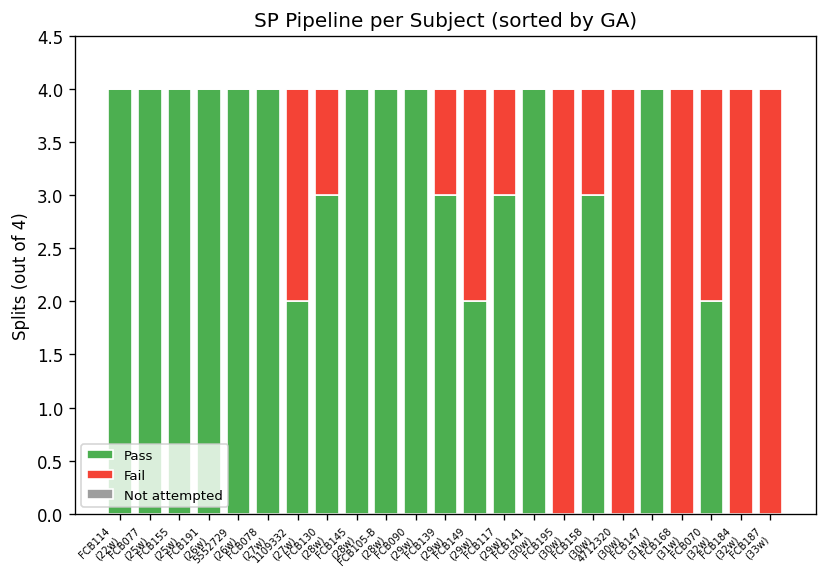

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(7, 5))

sp_summary = (
    df.groupby("subject_id")
    .agg(
        GA=("GA", "first"),
        n_pass=("sp_failed", lambda x: (~x).sum()),
        n_fail=("sp_failed", lambda x: x.sum()),
        n_not_attempted=("sp_not_attempted", "sum"),
    )
    .sort_values("GA")
)

x = range(len(sp_summary))
ax.bar(x, sp_summary["n_pass"], label="Pass", color="#4CAF50", edgecolor="white")
ax.bar(
    x,
    sp_summary["n_fail"],
    bottom=sp_summary["n_pass"],
    label="Fail",
    color="#F44336",
    edgecolor="white",
)
ax.bar(
    x,
    sp_summary["n_not_attempted"],
    bottom=sp_summary["n_pass"] + sp_summary["n_fail"],
    label="Not attempted",
    color="#9E9E9E",
    edgecolor="white",
)
ax.set_xticks(x)
ax.set_xticklabels(
    [f"{s}\n({g:.0f}w)" for s, g in zip(sp_summary.index, sp_summary["GA"])],
    fontsize=6,
    rotation=45,
    ha="right",
)
ax.set_ylabel("Splits (out of 4)")
ax.set_title("SP Pipeline per Subject (sorted by GA)")
ax.legend(fontsize=8)
ax.set_ylim(0, 4.5)

plt.tight_layout()
plt.savefig("plot_02_sp_failures.png", bbox_inches="tight")
plt.show()

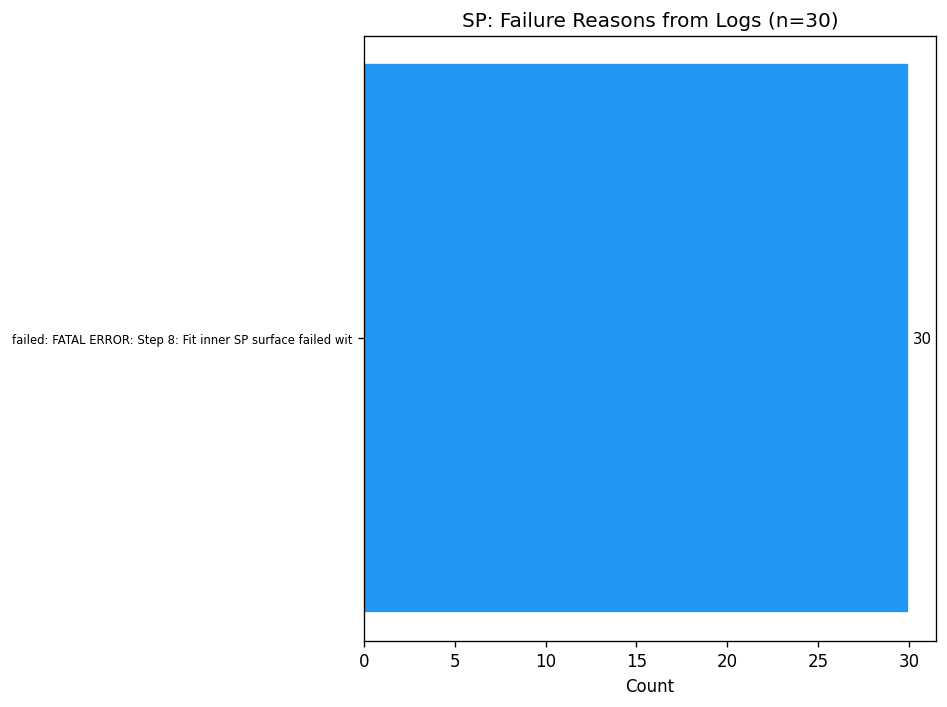

In [24]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# --- Panel B: SP failure reasons from log parsing ---
sp_fail_df = df[df["sp_failed"]].copy()
if not sp_fail_df.empty and "sp_log_status" in sp_fail_df.columns:
    log_statuses = sp_fail_df["sp_log_status"].fillna("no_log").value_counts()
    bars = ax.barh(
        range(len(log_statuses)),
        log_statuses.values,
        color="#2196F3",
        edgecolor="white",
    )
    ax.set_yticks(range(len(log_statuses)))
    labels = [str(s)[:60] for s in log_statuses.index]
    ax.set_yticklabels(labels, fontsize=7)
    ax.set_xlabel("Count")
    ax.set_title(f"SP: Failure Reasons from Logs (n={len(sp_fail_df)})")
    for bar, v in zip(bars, log_statuses.values):
        ax.text(
            v + 0.2, bar.get_y() + bar.get_height() / 2, str(v), va="center", fontsize=9
        )
elif not sp_fail_df.empty:
    # Fallback: just show status types
    sp_status_counts = sp_fail_df["sp_status"].value_counts()
    bars = ax.barh(
        range(len(sp_status_counts)),
        sp_status_counts.values,
        color="#2196F3",
        edgecolor="white",
    )
    ax.set_yticks(range(len(sp_status_counts)))
    ax.set_yticklabels(sp_status_counts.index, fontsize=8)
    ax.set_xlabel("Count")
    ax.set_title(f"SP: Failure Status Types (n={len(sp_fail_df)})")
else:
    ax.text(
        0.5,
        0.5,
        "No SP failures!",
        ha="center",
        va="center",
        transform=ax.transAxes,
        fontsize=14,
    )
    ax.set_title("SP Failure Reasons")

plt.tight_layout()
plt.savefig("plot_04_failure_reasons.png", bbox_inches="tight")
plt.show()

# Surface area plots

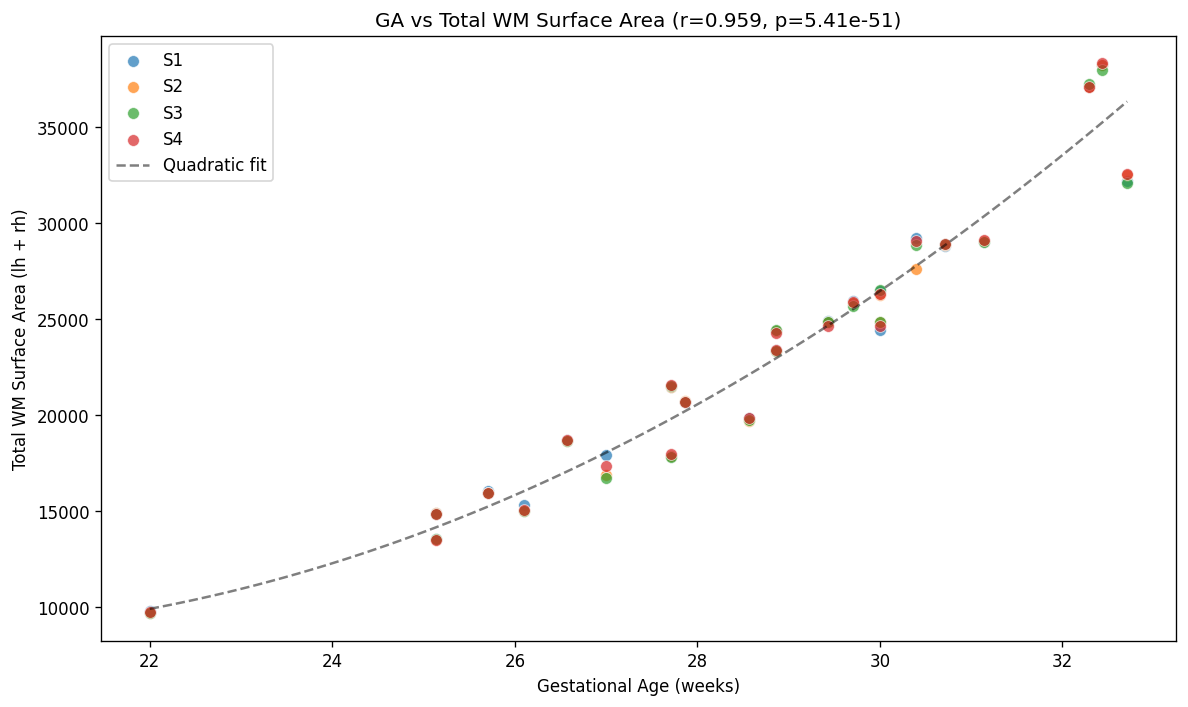

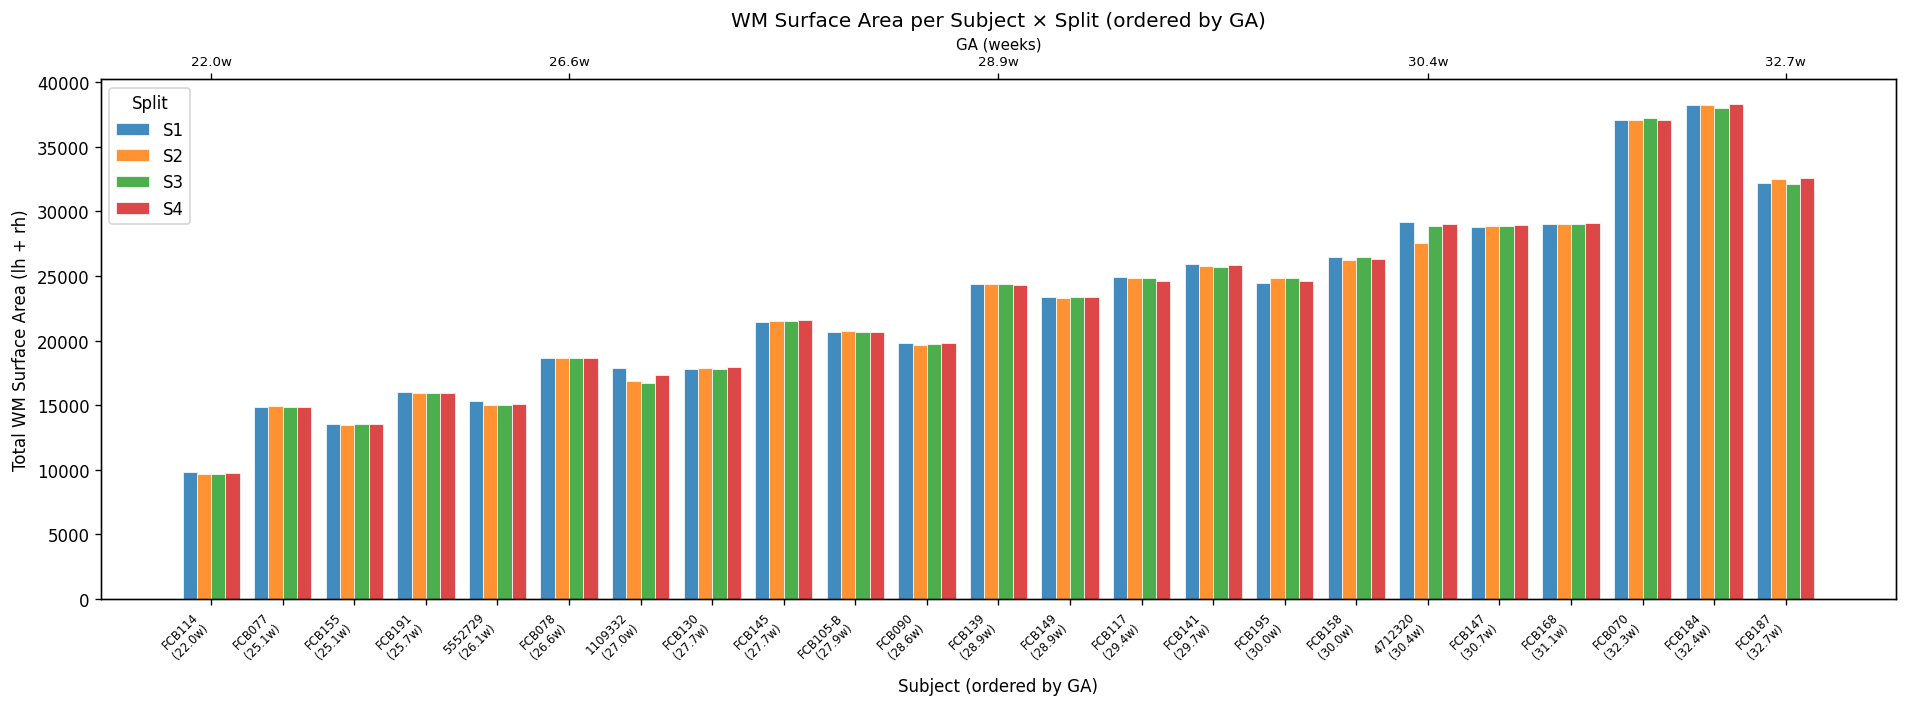

In [5]:
if "total_wm_area" in df.columns and df["total_wm_area"].notna().any():
    fig, ax = plt.subplots(figsize=(10, 6))

    valid = df[df["total_wm_area"].notna()].copy()

    split_colors = {"S1": "#1f77b4", "S2": "#ff7f0e", "S3": "#2ca02c", "S4": "#d62728"}

    for split, grp in valid.groupby("split"):
        ax.scatter(
            grp["GA"],
            grp["total_wm_area"],
            c=split_colors[split],
            label=split,
            alpha=0.7,
            s=50,
            edgecolors="white",
            linewidth=0.5,
        )

    # Fit overall trend line
    from numpy.polynomial import polynomial as P

    x_all, y_all = valid["GA"].values, valid["total_wm_area"].values
    mask_finite = np.isfinite(x_all) & np.isfinite(y_all)
    if mask_finite.sum() > 3:
        coeffs = np.polyfit(x_all[mask_finite], y_all[mask_finite], 2)
        x_fit = np.linspace(x_all[mask_finite].min(), x_all[mask_finite].max(), 100)
        y_fit = np.polyval(coeffs, x_fit)
        ax.plot(x_fit, y_fit, "k--", alpha=0.5, linewidth=1.5, label="Quadratic fit")

    # Correlation
    from scipy import stats

    r, p = stats.pearsonr(x_all[mask_finite], y_all[mask_finite])
    ax.set_title(f"GA vs Total WM Surface Area (r={r:.3f}, p={p:.2e})")

    ax.set_xlabel("Gestational Age (weeks)")
    ax.set_ylabel("Total WM Surface Area (lh + rh)")
    ax.legend()

    plt.tight_layout()
    plt.savefig("plot_05_ga_vs_wm_area.png", bbox_inches="tight")
    plt.show()

if "total_wm_area" in df.columns and df["total_wm_area"].notna().any():
    valid = df[df["total_wm_area"].notna()].copy()

    # Sort subjects by GA
    subj_ga = valid.groupby("subject_id")["GA"].first().sort_values()
    subj_order = subj_ga.index.tolist()

    split_colors = {"S1": "#1f77b4", "S2": "#ff7f0e", "S3": "#2ca02c", "S4": "#d62728"}

    fig, ax = plt.subplots(figsize=(16, 6))

    n_subjects = len(subj_order)
    n_splits = len(SPLITS) if "SPLITS" in dir() else 4
    bar_width = 0.2
    splits_present = sorted(valid["split"].unique())

    for i, split in enumerate(splits_present):
        split_data = valid[valid["split"] == split].set_index("subject_id")
        x_positions = []
        y_values = []

        for j, subj in enumerate(subj_order):
            if subj in split_data.index:
                x_positions.append(j + (i - len(splits_present) / 2 + 0.5) * bar_width)
                y_values.append(split_data.loc[subj, "total_wm_area"])

        ax.bar(
            x_positions,
            y_values,
            width=bar_width,
            color=split_colors[split],
            label=split,
            edgecolor="white",
            linewidth=0.5,
            alpha=0.85,
        )

    ax.set_xticks(range(n_subjects))
    ax.set_xticklabels(
        [f"{s}\n({subj_ga[s]:.1f}w)" for s in subj_order],
        fontsize=7,
        rotation=45,
        ha="right",
    )
    ax.set_xlabel("Subject (ordered by GA)")
    ax.set_ylabel("Total WM Surface Area (lh + rh)")
    ax.set_title("WM Surface Area per Subject × Split (ordered by GA)")
    ax.legend(title="Split")

    # Add GA axis on top
    ax2 = ax.twiny()
    ax2.set_xlim(ax.get_xlim())
    ga_ticks = [
        0,
        n_subjects // 4,
        n_subjects // 2,
        3 * n_subjects // 4,
        n_subjects - 1,
    ]
    ga_ticks = [t for t in ga_ticks if t < n_subjects]
    ax2.set_xticks(ga_ticks)
    ax2.set_xticklabels([f"{subj_ga.iloc[t]:.1f}w" for t in ga_ticks], fontsize=8)
    ax2.set_xlabel("GA (weeks)", fontsize=9)

    plt.tight_layout()
    plt.savefig("plot_06_surface_area_bars.png", bbox_inches="tight")
    plt.show()

In [31]:
# Load image quality metrics
iqm_path = "../data/image_quality_metrics.csv"
iq_df = pd.read_csv(iqm_path)

# Drop wm_surface_area column if it already exists
if "wm_surface_area" in iq_df.columns:
  iq_df = iq_df.drop(columns=["wm_surface_area"])
  print("Dropped existing 'wm_surface_area' column")

# Prepare surface area data from valid dataframe
surface_area_data = valid[["subject_id", "session_id", "split", "total_wm_area"]].copy()
surface_area_data = surface_area_data.rename(columns={"total_wm_area": "wm_surface_area"})

# Check which columns exist in iq_df for merging
merge_cols = []
if "subject_id" in iq_df.columns:
  merge_cols.append("subject_id")
if "session_id" in iq_df.columns:
  merge_cols.append("session_id")
if "split" in iq_df.columns:
  merge_cols.append("split")

print(f"Merging on columns: {merge_cols}")

# Merge surface area into image quality metrics
if merge_cols:
    iq_df = iq_df.merge(surface_area_data, on=merge_cols, how="left")
    print(
        f"\nMerged surface area data. Non-null values: {iq_df['wm_surface_area'].notna().sum()}/{len(iq_df)}"
    )

    # Save updated file
    iq_df.to_csv(iqm_path, index=False)
    print("Saved updated image_quality_metrics.csv")
else:
    print("ERROR: No matching columns found for merging!")

Merging on columns: ['subject_id', 'session_id', 'split']

Merged surface area data. Non-null values: 92/92
Saved updated image_quality_metrics.csv


In [28]:
failures = df[df["any_failed"]].copy()
if not failures.empty:
    summary_cols = ["subject_id", "split", "GA", "cp_status", "sp_status"]
    extra_cols = [
        c for c in ["sp_log_status", "cp_critical_missing"] if c in failures.columns
    ]
    display_cols = summary_cols + extra_cols

    failure_table = failures[display_cols].sort_values(["GA", "subject_id", "split"])
    print(f"\n{'='*80}")
    print(
        f"ALL FAILURES: {len(failure_table)} rows across {failure_table['subject_id'].nunique()} subjects"
    )
    print(f"{'='*80}")
    print(failure_table.to_string(index=False))
else:
    print("No failures detected!")


ALL FAILURES: 30 rows across 12 subjects
subject_id split    GA cp_status    sp_status                                                             sp_log_status cp_critical_missing
   1109332    S1 27.00  complete partial_fail failed: FATAL ERROR: Step 8: Fit inner SP surface failed with exit code 1                  []
   1109332    S4 27.00  complete partial_fail failed: FATAL ERROR: Step 8: Fit inner SP surface failed with exit code 1                  []
    FCB130    S1 27.71  complete partial_fail failed: FATAL ERROR: Step 8: Fit inner SP surface failed with exit code 1                  []
    FCB139    S4 28.86  complete partial_fail failed: FATAL ERROR: Step 8: Fit inner SP surface failed with exit code 1                  []
    FCB149    S2 28.86  complete partial_fail failed: FATAL ERROR: Step 8: Fit inner SP surface failed with exit code 1                  []
    FCB149    S3 28.86  complete partial_fail failed: FATAL ERROR: Step 8: Fit inner SP surface failed with exit code 

# Statistical analysis

In [ ]:
# Load image quality metrics (QA, CNR, etc.)
try:
    iqm_df = pd.read_csv("../data/image_quality_metrics.csv")
    print(f"Loaded image quality metrics: {len(iqm_df)} rows")
    print(f"Available columns: {', '.join(iqm_df.columns)}\n")
    
    # Merge with surface audit data to get failure status
    merged = iqm_df.merge(
        df[["subject_id", "session_id", "split", "sp_failed", "any_failed", "GA"]],
        on=["subject_id", "session_id", "split"],
        how="inner"
    )
    print(f"Merged data: {len(merged)} rows, {merged['subject_id'].nunique()} subjects\n")
    
    # 1. PRELIMINARY T-TEST: Simple comparison between green vs orange (as requested)
    print("="*80)
    print("STEP 1: Simple t-tests between green (all passed) and orange (any failed)")
    print("="*80)
    
    # Classify subjects based on whether they had ANY failures across all splits
    subj_fail_status = df.groupby("subject_id")["sp_failed"].any().reset_index()
    subj_fail_status["group"] = np.where(subj_fail_status["sp_failed"], "orange", "green")
    
    # Merge failure status with image quality metrics
    merged = merged.merge(
        subj_fail_status[["subject_id", "group"]], 
        on="subject_id", 
        how="left"
    )
    
    # Separate into green and orange groups
    green_data = merged[merged["group"] == "green"]
    orange_data = merged[merged["group"] == "orange"]
    
    print(f"\nGreen group: {green_data['subject_id'].nunique()} subjects, {len(green_data)} observations")
    print(f"Orange group: {orange_data['subject_id'].nunique()} subjects, {len(orange_data)} observations\n")
    
    # Test metrics of interest - check what's actually available
    metrics_to_test = []
    
    # CNR metrics
    if "cnr_sp_cp" in merged.columns:
        metrics_to_test.append(("cnr_sp_cp", "CNR (subplate-cortical plate)"))
    if "cnr_sp_inner" in merged.columns:
        metrics_to_test.append(("cnr_sp_inner", "CNR (subplate-inner)"))
    if "sp_iz_cnr" in merged.columns:
        metrics_to_test.append(("sp_iz_cnr", "CNR (subplate-IZ)"))
    
    # SNR metrics
    if "snr_subplate" in merged.columns:
        metrics_to_test.append(("snr_subplate", "SNR (subplate)"))
    if "snr_cortical_plate" in merged.columns:
        metrics_to_test.append(("snr_cortical_plate", "SNR (cortical plate)"))
    
    # Volume metrics
    if "sp_volume_voxels" in merged.columns:
        metrics_to_test.append(("sp_volume_voxels", "Subplate Volume"))
    if "cp_volume_voxels" in merged.columns:
        metrics_to_test.append(("cp_volume_voxels", "Cortical Plate Volume"))
    
    # Other metrics
    if "scaling_factor" in merged.columns:
        metrics_to_test.append(("scaling_factor", "Scaling Factor"))
    
    # Always test GA
    metrics_to_test.append(("GA", "Gestational Age"))
    
    print("Simple t-tests (per-split observations, not accounting for repeated measures):")
    print("-" * 80)
    
    simple_results = []
    for metric_col, metric_name in metrics_to_test:
        if metric_col in merged.columns:
            green_vals = green_data[metric_col].dropna().values
            orange_vals = orange_data[metric_col].dropna().values
            
            if len(green_vals) > 0 and len(orange_vals) > 0:
                t_stat, p_val = stats.ttest_ind(green_vals, orange_vals, equal_var=False)
                simple_results.append({
                    "Metric": metric_name,
                    "Green_mean": green_vals.mean(),
                    "Green_std": green_vals.std(),
                    "Orange_mean": orange_vals.mean(),
                    "Orange_std": orange_vals.std(),
                    "t": t_stat,
                    "p": p_val
                })
    
    simple_df = pd.DataFrame(simple_results)
    for _, row in simple_df.iterrows():
        sig = "***" if row['p'] < 0.001 else "**" if row['p'] < 0.01 else "*" if row['p'] < 0.05 else "n.s."
        print(f"{row['Metric']:20s}: Green={row['Green_mean']:8.2f}±{row['Green_std']:.2f}, "
              f"Orange={row['Orange_mean']:8.2f}±{row['Orange_std']:.2f}, "
              f"t={row['t']:6.3f}, p={row['p']:.4f} {sig}")
    
    # 2. WEIGHTED ANALYSIS: Account for repeated measures by averaging per subject
    print("\n" + "="*80)
    print("STEP 2: Weighted analysis (mean per subject, accounting for repeated measures)")
    print("="*80)
    print("\nComputing mean values per subject across all splits...")
    
    # Build aggregation dictionary for available metrics
    agg_dict = {}
    for metric_col, _ in metrics_to_test:
        if metric_col in merged.columns:
            agg_dict[metric_col] = "mean"
    
    # Compute per-subject means
    if agg_dict:
        subj_means = merged.groupby(["subject_id", "group"]).agg(agg_dict).reset_index()
    else:
        print("ERROR: No valid metrics found to aggregate")
        raise ValueError("No metrics available for analysis")
    
    # Separate groups
    green_subj = subj_means[subj_means["group"] == "green"]
    orange_subj = subj_means[subj_means["group"] == "orange"]
    
    print(f"\nGreen group: {len(green_subj)} subjects")
    print(f"Orange group: {len(orange_subj)} subjects\n")
    
    print("Subject-level t-tests (accounting for repeated measures):")
    print("-" * 80)
    
    weighted_results = []
    for metric_col, metric_name in metrics_to_test:
        if metric_col in subj_means.columns:
            green_vals = green_subj[metric_col].dropna().values
            orange_vals = orange_subj[metric_col].dropna().values
            
            if len(green_vals) > 0 and len(orange_vals) > 0:
                t_stat, p_val = stats.ttest_ind(green_vals, orange_vals, equal_var=False)
                
                # Calculate Cohen's d (effect size)
                pooled_std = np.sqrt(((len(green_vals)-1)*green_vals.std()**2 + 
                                     (len(orange_vals)-1)*orange_vals.std()**2) / 
                                    (len(green_vals) + len(orange_vals) - 2))
                cohens_d = (orange_vals.mean() - green_vals.mean()) / pooled_std if pooled_std > 0 else 0
                
                weighted_results.append({
                    "Metric": metric_name,
                    "Green_mean": green_vals.mean(),
                    "Green_std": green_vals.std(),
                    "Orange_mean": orange_vals.mean(),
                    "Orange_std": orange_vals.std(),
                    "t": t_stat,
                    "p": p_val,
                    "Cohen_d": cohens_d
                })
    
    weighted_df = pd.DataFrame(weighted_results)
    for _, row in weighted_df.iterrows():
        sig = "***" if row['p'] < 0.001 else "**" if row['p'] < 0.01 else "*" if row['p'] < 0.05 else "n.s."
        effect = "large" if abs(row['Cohen_d']) >= 0.8 else "medium" if abs(row['Cohen_d']) >= 0.5 else "small" if abs(row['Cohen_d']) >= 0.2 else "negligible"
        print(f"{row['Metric']:20s}: Green={row['Green_mean']:8.2f}±{row['Green_std']:.2f}, "
              f"Orange={row['Orange_mean']:8.2f}±{row['Orange_std']:.2f}, "
              f"t={row['t']:6.3f}, p={row['p']:.4f} {sig}, d={row['Cohen_d']:.2f} ({effect})")
    
    print("\n" + "="*80)
    print("SUMMARY:")
    print("="*80)
    print("Step 1 shows per-split comparisons (inflated by repeated measures).")
    print("Step 2 accounts for repeated measures by averaging across splits per subject.")
    print("Step 2 is more appropriate for statistical inference (correct degrees of freedom).")
    
except FileNotFoundError:
    print("ERROR: Could not find ../data/image_quality_metrics.csv")
    print("This analysis requires image quality metrics (QA, CNR, etc.)")
except KeyError as e:
    print(f"ERROR: Missing expected column: {e}")
    print("Available columns:", iqm_df.columns.tolist() if 'iqm_df' in locals() else "N/A")

Loaded image quality metrics: 92 rows
Available columns: subject_id, session_id, GA, split, snr_subplate, snr_cortical_plate, snr_inner, cnr_sp_cp, cnr_sp_inner, cnr_cp_inner, sp_mean_intensity, sp_std_intensity, sp_volume_voxels, cp_mean_intensity, cp_std_intensity, cp_volume_voxels, inner_mean_intensity, inner_std_intensity, inner_volume_voxels, scaling_factor, native_vol_sp, native_vol_cp, native_vol_inner, wm_surface_area, sp_iz_cnr

Merged data: 92 rows, 23 subjects

STEP 1: Simple t-tests between green (all passed) and orange (any failed)

Green group: 11 subjects, 44 observations
Orange group: 12 subjects, 48 observations

Simple t-tests (per-split observations, not accounting for repeated measures):
--------------------------------------------------------------------------------
CNR (subplate-cortical plate): Green=    2.93±0.10, Orange=    2.63±0.17, t=10.095, p=0.0000 ***
CNR (subplate-inner): Green=    0.10±0.07, Orange=    0.09±0.06, t= 0.570, p=0.5702 n.s.
CNR (subplate-IZ

# GA vs WM analysis

Green group (all passed): 11 subjects
Orange group (any failed): 12 subjects

GA comparison (Welch's t-test):
  Green: mean=26.84 ± 2.32 weeks (n=11)
  Orange: mean=30.07 ± 1.76 weeks (n=12)
  t=-3.572, p=0.0021

Total WM Surface Area comparison (Welch's t-test):
  Green: mean=18584.1 ± 5312.2 (n=11)
  Orange: mean=27005.7 ± 6285.0 (n=12)
  t=-3.326, p=0.0032

Mann-Whitney U (non-parametric):
  GA: U=18.5, p=0.0038
  WM Area: U=22.0, p=0.0074



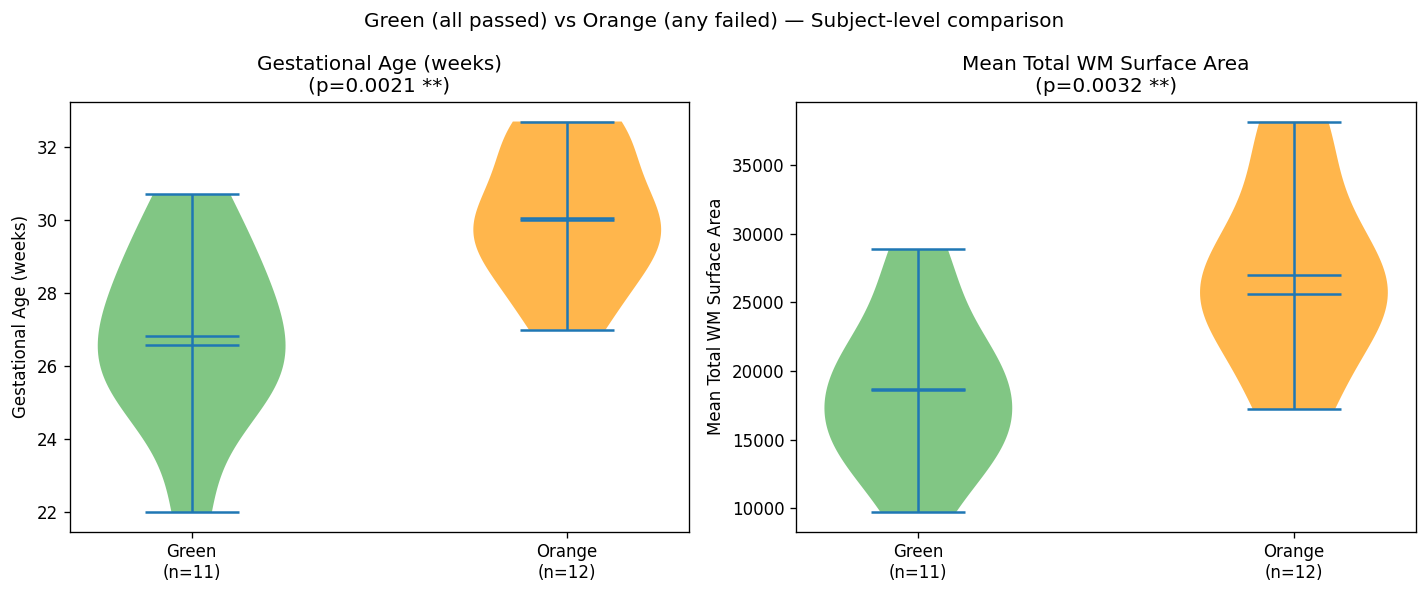

In [ ]:
from scipy import stats

# Classify subjects: green (all passed) vs orange (any failed)
subj_summary = df.groupby("subject_id").agg(
  GA=("GA", "first"),
  n_pass=("sp_failed", lambda x: (~x).sum()),
  n_fail=("sp_failed", lambda x: x.sum()),
  total_wm_area_mean=("total_wm_area", "mean"),
).dropna(subset=["total_wm_area_mean"])

subj_summary["group"] = np.where(subj_summary["n_fail"] == 0, "green", "orange")
green = subj_summary[subj_summary["group"] == "green"]
orange = subj_summary[subj_summary["group"] == "orange"]

print(f"Green group (all passed): {len(green)} subjects")
print(f"Orange group (any failed): {len(orange)} subjects\n")

# Subject-level comparisons
green_ga, green_area = green["GA"].values, green["total_wm_area_mean"].values
orange_ga, orange_area = orange["GA"].values, orange["total_wm_area_mean"].values

# Welch's t-tests (don't assume equal variance)
t_ga, p_ga = stats.ttest_ind(green_ga, orange_ga, equal_var=False)
t_area, p_area = stats.ttest_ind(green_area, orange_area, equal_var=False)

print(f"GA comparison (Welch's t-test):")
print(f"  Green: {green_ga.mean():.2f} ± {green_ga.std():.2f} weeks")
print(f"  Orange: {orange_ga.mean():.2f} ± {orange_ga.std():.2f} weeks")
print(f"  t={t_ga:.3f}, p={p_ga:.4f}\n")

print(f"WM Surface Area comparison (Welch's t-test):")
print(f"  Green: {green_area.mean():.1f} ± {green_area.std():.1f}")
print(f"  Orange: {orange_area.mean():.1f} ± {orange_area.std():.1f}")
print(f"  t={t_area:.3f}, p={p_area:.4f}\n")

# Mann-Whitney U (non-parametric alternative)
u_ga, p_u_ga = stats.mannwhitneyu(green_ga, orange_ga, alternative="two-sided")
u_area, p_u_area = stats.mannwhitneyu(green_area, orange_area, alternative="two-sided")
print(f"Mann-Whitney U (non-parametric):")
print(f"  GA: U={u_ga:.1f}, p={p_u_ga:.4f}")
print(f"  WM Area: U={u_area:.1f}, p={p_u_area:.4f}\n")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, metric, label, pval in zip(
  axes, ["GA", "total_wm_area_mean"],
  ["Gestational Age (weeks)", "Mean Total WM Surface Area"],
  [p_ga, p_area]
):
  green_vals, orange_vals = green[metric].values, orange[metric].values
  parts = ax.violinplot([green_vals, orange_vals], positions=[0, 1], showmeans=True, showmedians=True)
  for i, color in enumerate(["#4CAF50", "#FF9800"]):
    parts["bodies"][i].set_facecolor(color)
    parts["bodies"][i].set_alpha(0.7)
  ax.set_xticks([0, 1])
  ax.set_xticklabels([f"Green\n(n={len(green_vals)})", f"Orange\n(n={len(orange_vals)})"])
  ax.set_ylabel(label)
  sig = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else "n.s."
  ax.set_title(f"{label}\n(p={pval:.4f} {sig})")

plt.suptitle("Green (all passed) vs Orange (any failed) — Subject-level comparison", fontsize=12)
plt.tight_layout()
plt.savefig("plot_07_green_vs_orange.png", bbox_inches="tight")
plt.show()

In [7]:
# ANCOVA: Test if group affects WM area after controlling for GA
from scipy import stats
import scipy.stats as st

# Prepare data for ANCOVA
green_data = green[["GA", "total_wm_area_mean"]].copy()
green_data["group"] = 0
orange_data = orange[["GA", "total_wm_area_mean"]].copy()
orange_data["group"] = 1

combined = pd.concat([green_data, orange_data])

# Fit linear regression: WM_area ~ GA + group
from scipy.stats import linregress

# Model 1: WM area ~ GA only (reduced model)
slope_ga, intercept_ga, r_ga, p_ga_only, se_ga = linregress(combined["GA"], combined["total_wm_area_mean"])
y_pred_ga_only = slope_ga * combined["GA"] + intercept_ga
ss_residual_reduced = np.sum((combined["total_wm_area_mean"] - y_pred_ga_only) ** 2)

# Model 2: WM area ~ GA + group (full model)
# Using simple approach: test if group is significant after accounting for GA
# Get residuals after removing GA effect
ga_residuals = combined["total_wm_area_mean"] - y_pred_ga_only

# Test if residuals differ by group
green_resid = ga_residuals[combined["group"] == 0].values
orange_resid = ga_residuals[combined["group"] == 1].values

t_resid, p_resid = stats.ttest_ind(green_resid, orange_resid, equal_var=False)

print("="*80)
print("ANCOVA: Does group predict WM area after controlling for GA?")
print("="*80)
print(f"\nGA effect on WM area: r²={r_ga**2:.3f}, p={p_ga_only:.4f}")
print(f"\nGA-adjusted residuals (WM area after removing GA effect):")
print(f"  Green residuals: mean={green_resid.mean():.1f} ± {green_resid.std():.1f}")
print(f"  Orange residuals: mean={orange_resid.mean():.1f} ± {orange_resid.std():.1f}")
print(f"  t={t_resid:.3f}, p={p_resid:.4f}")

if p_resid < 0.05:
    print(f"\n✓ Group effect REMAINS significant after controlling for GA (p={p_resid:.4f})")
    print("  → Pipeline failures are associated with larger WM area independent of age")
else:
    print(f"\n✗ Group effect is NOT significant after controlling for GA (p={p_resid:.4f})")
    print("  → The WM area difference is likely explained by the GA difference")

# Effect size (Cohen's d) for the original comparison
pooled_std = np.sqrt(((len(green_area) - 1) * green_area.std()**2 + 
                      (len(orange_area) - 1) * orange_area.std()**2) / 
                     (len(green_area) + len(orange_area) - 2))
cohens_d = (orange_area.mean() - green_area.mean()) / pooled_std

print(f"\nEffect size (Cohen's d) for WM area difference: {cohens_d:.2f}")
print(f"  Interpretation: ", end="")
if abs(cohens_d) < 0.2:
    print("negligible")
elif abs(cohens_d) < 0.5:
    print("small")
elif abs(cohens_d) < 0.8:
    print("medium")
else:
    print("large")

ANCOVA: Does group predict WM area after controlling for GA?

GA effect on WM area: r²=0.920, p=0.0000

GA-adjusted residuals (WM area after removing GA effect):
  Green residuals: mean=73.4 ± 1710.2
  Orange residuals: mean=-67.2 ± 2292.3
  t=0.160, p=0.8743

✗ Group effect is NOT significant after controlling for GA (p=0.8743)
  → The WM area difference is likely explained by the GA difference

Effect size (Cohen's d) for WM area difference: 1.44
  Interpretation: large
